In [2]:
import gymnasium as gym
from collections import deque
import numpy as np
from torch import optim
from torch import nn
import torch
import random
import matplotlib.pyplot as plt
import os

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
device = torch.device("cpu")
print(f"device: {device}")


from myQnet import QNetwork

device: cpu


In [3]:
main_dir = os.getcwd()
video_dir = os.path.join(main_dir, "videos")
model_dir = os.path.join(main_dir, "models")

if not os.path.exists(video_dir):
    os.makedirs(video_dir)
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

In [4]:
env = gym.make(
    "LunarLander-v3", 
    continuous=False, 
    gravity= -10, 
    enable_wind=False, 
    wind_power=15, 
    turbulence_power=1.5)


obs_space = env.observation_space
action_space = env.action_space

print(f"obs_space: {obs_space}")
print(f"action_space: {action_space}")
print(f"obs.space shape: {obs_space.shape}")
print(f"action_space shape: {action_space.n}")

## action space
# 0: do nothing
# 1: fire left engine
# 2: fire main engine
# 3: fire right engine

## observation space
# 0: x-position
# 1: y-position
# 2: x-velocity
# 3: y-velocity
# 4: angle
# 5: angular velocity
# 6: leg contact 1 
# 7: leg contact 2

## reward

# increased/decreased the closer/further the lander to target pad
# increased/decreased the slower/faster the lander is moving
# decreased the more the lander is titled (angle not horizontal)
# increased by 10 points for each leg in contact with the ground

# -100: crashed
# +100: landed

# -0.03 each frame a side eigine is firing
# -0.3 each frame a main engine is firing

## termination
# 1. lander crashes
# 2. lander landed
# 3. lander is not awake (not moving and collding)



obs_space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
action_space: Discrete(4)
obs.space shape: (8,)
action_space shape: 4


/opt/miniconda3/envs/pytorch_csiro/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [5]:
obs, info = env.reset()

done = False
total_reward = 0

while not done:
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward 
    obs = next_obs

    done = terminated or truncated
print(f"Total reward: {total_reward}")

Total reward: -119.87239081725359


In [6]:
## Setting up Qnet

state_dim = obs_space.shape[0]; print(f"state_dim: {state_dim}")
action_dim = action_space.n; print(f"action_dim: {action_dim}")

hidden_dim = 32
qnet = QNetwork(state_dim, action_dim, hidden_dim=hidden_dim).to(device)
target_net = QNetwork(state_dim, action_dim, hidden_dim=hidden_dim).to(device)
target_net.load_state_dict(qnet.state_dict())

for params in qnet.parameters():
    print(params.shape)

state_dim: 8
action_dim: 4
torch.Size([32, 8])
torch.Size([32])
torch.Size([32, 32])
torch.Size([32])
torch.Size([4, 32])
torch.Size([4])


In [7]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self,batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones =  zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int32),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

In [8]:
def select_action(state, qnet, epsilon, action_dim, device):
    if random.random() < epsilon:
        return random.randrange(action_dim)

    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = qnet(state)
        return q_values.argmax(dim=1).item()

def train_step(qnet, target_net, buffer, optimizer, batch_size, beta, device):

    if len(buffer) < batch_size:
        return None

    state, action, reward, next_state, done = buffer.sample(batch_size)

    states = torch.tensor(state, dtype=torch.float32, device=device)
    actions = torch.tensor(action, dtype=torch.int32, device=device).unsqueeze(1)
    rewards = torch.tensor(reward, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(next_state, dtype=torch.float32, device=device)
    dones = torch.tensor(done, dtype=torch.float32, device=device).unsqueeze(1)
    
    q_values = qnet(states).gather(1, actions)
 
    with torch.no_grad(): # double q
        next_q = target_net(next_states).max(dim=1, keepdim=True)[0]
        # next_action = qnet(next_states).argmax(dim=1, keepdim=True)
        # next_q = target_net(next_states).gather(1, next_action)
        target = rewards + beta * ( 1 - dones ) * next_q

    loss = nn.MSELoss()(q_values, target)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

def Evaluate(env, qnet,num_episodes, device):
    rewards = []

    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action = qnet(state).argmax(dim=1).item()
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    return np.mean(rewards), np.std(rewards)


In [11]:
buffer = ReplayBuffer(capacity=100000)
state, _ = env.reset()

for iter in range(1000):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    buffer.push(state, action, reward, next_state, done)
    state = next_state

    if done: 
        print(f"Episode {iter} finished, terminated: {terminated}, truncated: {truncated}")
        state, _ = env.reset()
print(len(buffer))

Episode 90 finished, terminated: True, truncated: False
Episode 196 finished, terminated: True, truncated: False
Episode 262 finished, terminated: True, truncated: False
Episode 369 finished, terminated: True, truncated: False
Episode 457 finished, terminated: True, truncated: False
Episode 547 finished, terminated: True, truncated: False
Episode 608 finished, terminated: True, truncated: False
Episode 693 finished, terminated: True, truncated: False
Episode 777 finished, terminated: True, truncated: False
Episode 893 finished, terminated: True, truncated: False
Episode 992 finished, terminated: True, truncated: False
1000


In [12]:
%%time 

NUM_EPISODES = 400
BATCH_SIZE = 64
GAMMA = 0.98
EPSILON = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.99

TARGET_UPDATE_FREQ = 50

BEST_EVAL = -float('inf')
EVAL_FREQ = 50
EVAL_EPISODES = 10
PATIENCE = 20
IMPROVEMENT_COUNT = 0
MIN_IMPROVEMENT = 5.0

optimizer = optim.Adam(qnet.parameters(), lr=5e-4)

episode_rewards = []
episode_losses = []
episode_epsilons = []


for epi in range(NUM_EPISODES):
    state, _ = env.reset()
    done = False
    total_reward = 0
    losses = []

    while not done:
        action = select_action(state, qnet, EPSILON, action_dim=action_dim, device=device) # get action from qnet
        next_state, reward, terminated, truncated, info = env.step(action) # take action in env
        done = terminated or truncated # check if done
        buffer.push(state, action, reward, next_state, done) # store transition in buffer

        loss = train_step(qnet, target_net, buffer, optimizer, batch_size=BATCH_SIZE, beta=0.95, device=device) # train qnet

        if loss is not None:
            losses.append(loss)
            
        state = next_state
        total_reward += reward

    # if epi % TARGET_UPDATE_FREQ == 0:
    #     target_net.load_state_dict(qnet.state_dict())
    #     print(f"Saved model at episode {epi}")

    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)
    avg_loss = np.mean(losses) if losses else 0
    
    episode_rewards.append(total_reward)
    episode_losses.append(avg_loss)
    episode_epsilons.append(EPSILON)
 
    if epi % EVAL_FREQ == 0:
        mean_eval, std_eval = Evaluate(env, qnet, num_episodes=EVAL_EPISODES, device=device)
        if mean_eval > BEST_EVAL:
            target_net.load_state_dict(qnet.state_dict())

            BEST_EVAL = mean_eval
            IMPROVEMENT_COUNT = 0
            torch.save(qnet.state_dict(), os.path.join(model_dir, f"best_lunar_lander_{hidden_dim}.pth"))
            print(f"Episode {epi:3d}: Mean reward {mean_eval:8.2f}, Std reward {std_eval:8.2f}, avg loss {avg_loss:8.4f}, epsilon {EPSILON:.3}")
        else: 
            print(f"No improvement on episode {epi}")
            IMPROVEMENT_COUNT += 1
        if IMPROVEMENT_COUNT >= PATIENCE:
            print(f"Early stopping on episode {epi}, no improvement in {PATIENCE} episodes")
            break

Episode   0: Mean reward  -227.56, Std reward   114.31, avg loss  89.1265, epsilon 0.97
No improvement on episode 50
Episode 100: Mean reward  -163.25, Std reward   170.14, avg loss  32.9506, epsilon 0.0461
No improvement on episode 150
No improvement on episode 200
No improvement on episode 250
Episode 300: Mean reward    -6.51, Std reward   226.06, avg loss  15.0923, epsilon 0.01
No improvement on episode 350
CPU times: user 50.3 s, sys: 1.86 s, total: 52.1 s
Wall time: 51.9 s


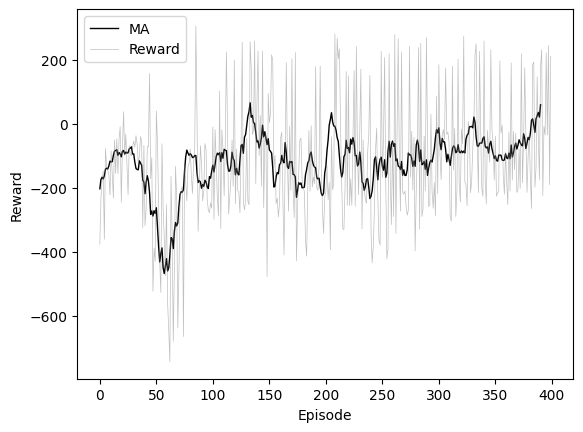

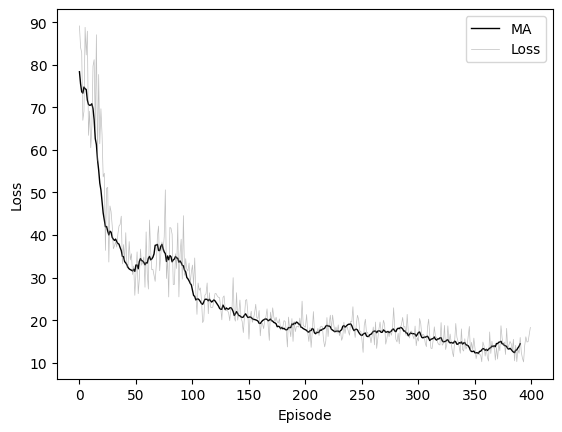

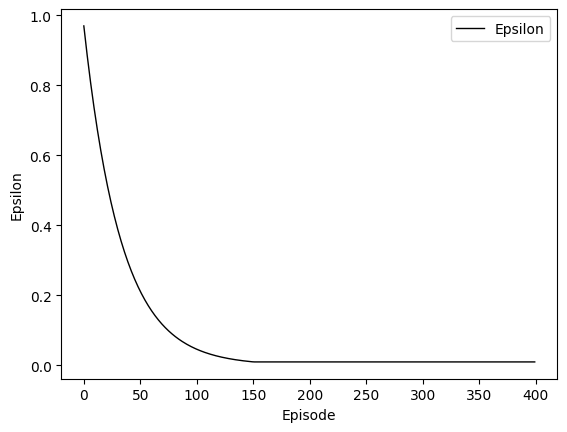

'\nCPU\nCPU times: user 4.48 s, sys: 318 ms, total: 4.8 s\nWall time: 4.74 s\n'

In [14]:
from matplotlib import pyplot as plt

def ma(data, window=10, mode='valid'):
    return np.convolve(np.array(data).flatten(), np.ones(window) / window, mode=mode)

plt.plot(ma(episode_rewards), c='black', lw=1, label= f'MA')
plt.plot(episode_rewards, c='gray', alpha=0.5, lw=0.5, label='Reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.savefig(os.path.join(model_dir, f'reward_{hidden_dim}.png')) 
plt.show()

plt.plot(ma(episode_losses), c='black', lw=1, label='MA')
plt.plot(episode_losses, c='gray', alpha=0.5, lw=0.5, label='Loss')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(model_dir, f'loss_{hidden_dim}.png'))
plt.show()

plt.plot(episode_epsilons, c='black', lw=1, label='Epsilon')
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.legend()
plt.savefig(os.path.join(model_dir, f'epsilon_{hidden_dim}.png'))
plt.show()

### GPU MPS WALL TIME 

"""
MPS
CPU times: user 16.9 s, sys: 4.74 s, total: 21.6 s
Wall time: 35.2 s
"""

"""
CPU
CPU times: user 4.48 s, sys: 318 ms, total: 4.8 s
Wall time: 4.74 s
"""
